# Khai thác Sức Mạnh GPU (A100) với RetinaFace & FaceNet
Notebook này sẽ giải nén tập dữ liệu LFW từ Drive, và chạy song song 2 detector (MTCNN và RetinaFace) trên GPU để đánh giá FaceNet.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Giải nén tập dữ liệu từ Google Drive thẳng vào ở đĩa siêu tốc của Colab (/content/)
!unrar x "/content/drive/MyDrive/Nam_3_HK_2/DACN/lfw_funneled.rar" "/content/" > /dev/null
print("Đã giải nén xong thư mục lfw_funneled vào /content/")

Đã giải nén xong thư mục lfw_funneled vào /content/


In [ ]:
# Cài đặt các thư viện cần thiết
!pip install deepface opencv-python pandas matplotlib scikit-learn tqdm tf-keras mtcnn
# Lưu ý Retinaface tự động được tải xuống khi dùng deepface với detector_backend='retinaface'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from deepface import DeepFace

DATASET_PATH = "/content/lfw_funneled"
PAIRS_FILE = os.path.join(DATASET_PATH, "pairs.txt")

# Đọc file pairs.txt
def load_pairs(pairs_file, dataset_path):
    pairs = []
    with open(pairs_file, 'r') as f:
        lines = f.readlines()[1:]
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 3:
                name, img1, img2 = parts[0], int(parts[1]), int(parts[2])
                p1 = os.path.join(dataset_path, name, f"{name}_{img1:04d}.jpg")
                p2 = os.path.join(dataset_path, name, f"{name}_{img2:04d}.jpg")
                pairs.append((p1, p2, 1))
            elif len(parts) == 4:
                name1, img1, name2, img2 = parts[0], int(parts[1]), parts[2], int(parts[3])
                p1 = os.path.join(dataset_path, name1, f"{name1}_{img1:04d}.jpg")
                p2 = os.path.join(dataset_path, name2, f"{name2}_{img2:04d}.jpg")
                pairs.append((p1, p2, 0))
    return pairs

pairs = load_pairs(PAIRS_FILE, DATASET_PATH)
unique_image_paths = set()
for p1, p2, _ in pairs:
    unique_image_paths.add(p1)
    unique_image_paths.add(p2)

print(f"Có tổng cộng {len(unique_image_paths)} ảnh cần trích xuất đặc trưng.")

26-04-24 04:14:39 - Directory /root/.deepface has been created
26-04-24 04:14:39 - Directory /root/.deepface/weights has been created
Có tổng cộng 7701 ảnh cần trích xuất đặc trưng.


In [ ]:
# Tạo thư mục trên Drive để lưu models
DRIVE_MODELS_DIR = "/content/drive/MyDrive/Nam_3_HK_2/DACN/models/precomputed"
os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)

DETECTORS = ["mtcnn", "retinaface"]
MODELS = ["Facenet", "Facenet512"]

def extract_and_save():
    for model_name in MODELS:
        for detector in DETECTORS:
            print(f"\n--- Đang chạy Model: {model_name} | Detector: {detector} ---")
            save_path = os.path.join(DRIVE_MODELS_DIR, f"{model_name}_{detector}_embeddings.pkl")

            if os.path.exists(save_path):
                print(f"File {save_path} đã tồn tại, bỏ qua...")
                continue

            embeddings_dict = {}
            # Bật GPU nếu có, DeepFace tự động dùng GPU cho RetinaFace
            for img_path in tqdm(unique_image_paths, desc=f"Ext {model_name}-{detector}"):
                try:
                    res = DeepFace.represent(img_path=img_path, model_name=model_name,
                                            detector_backend=detector, enforce_detection=False, align=True)
                    embeddings_dict[img_path] = res[0]['embedding']
                except Exception as e:
                    if model_name == "Facenet":
                        embeddings_dict[img_path] = np.zeros(128)
                    else:
                        embeddings_dict[img_path] = np.zeros(512)

            with open(save_path, 'wb') as f:
                pickle.dump(embeddings_dict, f)
            print(f"Đã lưu xong {save_path}")

# Chạy hàm trích xuất
extract_and_save()


--- Đang chạy Model: Facenet | Detector: mtcnn ---


Ext Facenet-mtcnn:   0%|          | 0/7701 [00:00<?, ?it/s]

26-04-24 04:14:43 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5

  0%|          | 0.00/92.2M [00:00<?, ?B/s]
 12%|█▏        | 11.0M/92.2M [00:00<00:00, 99.5MB/s]
 25%|██▌       | 23.1M/92.2M [00:00<00:00, 111MB/s] 
 49%|████▉     | 45.6M/92.2M [00:00<00:00, 160MB/s]
100%|██████████| 92.2M/92.2M [00:00<00:00, 189MB/s]
Ext Facenet-mtcnn: 100%|██████████| 7701/7701 [48:50<00:00,  2.63it/s]


Đã lưu xong /content/drive/MyDrive/Nam_3_HK_2/DACN/models/precomputed/Facenet_mtcnn_embeddings.pkl

--- Đang chạy Model: Facenet | Detector: retinaface ---


...

26-04-24 05:34:07 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /root/.deepface/weights/facenet512_weights.h5...



  0%|          | 0.00/95.0M [00:00<?, ?B/s]
  7%|▋         | 6.82M/95.0M [00:00<00:01, 66.7MB/s]
 25%|██▍       | 23.6M/95.0M [00:00<00:00, 124MB/s] 
 43%|████▎     | 40.4M/95.0M [00:00<00:00, 144MB/s]
 60%|██████    | 57.1M/95.0M [00:00<00:00, 153MB/s]
 78%|███████▊  | 73.9M/95.0M [00:00<00:00, 158MB/s]
100%|██████████| 95.0M/95.0M [00:00<00:00, 151MB/s]
Ext Facenet512-mtcnn: 100%|██████████| 7701/7701 [48:58<00:00,  2.62it/s]


Đã lưu xong /content/drive/MyDrive/Nam_3_HK_2/DACN/models/precomputed/Facenet512_mtcnn_embeddings.pkl

--- Đang chạy Model: Facenet512 | Detector: retinaface ---


Ext Facenet512-retinaface: 100%|██████████| 7701/7701 [31:08<00:00,  4.12it/s]


Đã lưu xong /content/drive/MyDrive/Nam_3_HK_2/DACN/models/precomputed/Facenet512_retinaface_embeddings.pkl


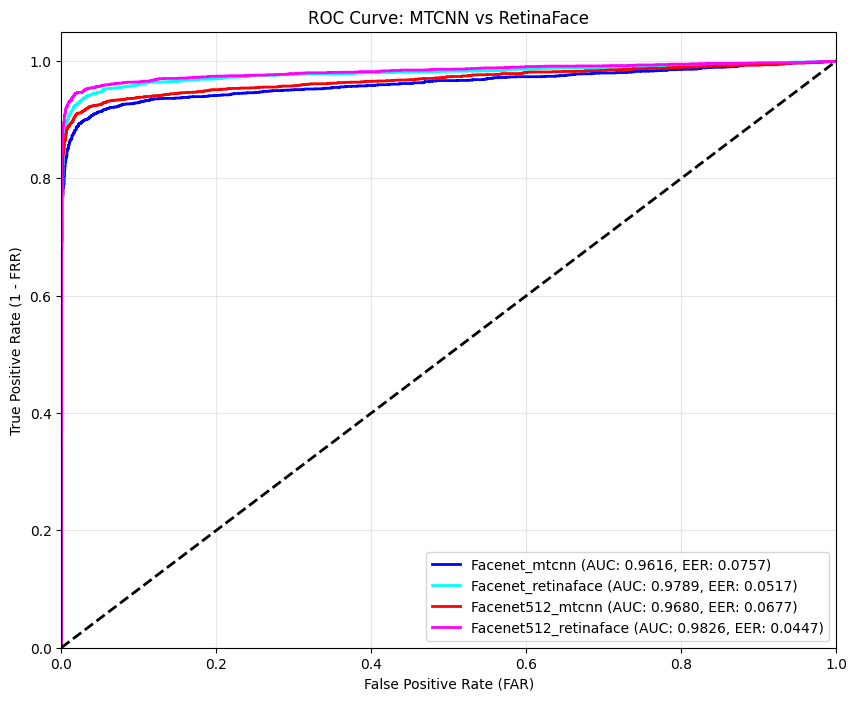

In [ ]:
from scipy.spatial.distance import cosine

def cosine_similarity(emb1, emb2):
    # Xử lý trường hợp mảng toàn số 0 (không nhận diện được mặt)
    if np.sum(emb1) == 0 or np.sum(emb2) == 0:
        return -1.0
    return 1 - cosine(emb1, emb2)

def plot_roc_comparison():
    plt.figure(figsize=(10, 8))
    colors = {'Facenet_mtcnn': 'blue', 'Facenet_retinaface': 'cyan',
              'Facenet512_mtcnn': 'red', 'Facenet512_retinaface': 'magenta'}

    for model_name in MODELS:
        for detector in DETECTORS:
            key = f"{model_name}_{detector}"
            save_path = os.path.join(DRIVE_MODELS_DIR, f"{key}_embeddings.pkl")

            with open(save_path, 'rb') as f:
                embs = pickle.load(f)

            y_true, similarities = [], []
            for p1, p2, is_same in pairs:
                e1, e2 = embs.get(p1), embs.get(p2)
                if e1 is not None and e2 is not None:
                    sim = cosine_similarity(e1, e2)
                    similarities.append(sim)
                    y_true.append(is_same)

            fpr, tpr, thres = roc_curve(y_true, similarities)
            roc_auc = auc(fpr, tpr)

            # Tìm EER
            frr = 1 - tpr
            far = fpr
            eer_idx = np.nanargmin(np.absolute(frr - far))
            eer = far[eer_idx]

            plt.plot(fpr, tpr, color=colors[key], lw=2,
                     label=f'{key} (AUC: {roc_auc:.4f}, EER: {eer:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FAR)')
    plt.ylabel('True Positive Rate (1 - FRR)')
    plt.title('ROC Curve: MTCNN vs RetinaFace')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    report_path = "/content/drive/MyDrive/Nam_3_HK_2/DACN/reports"
    os.makedirs(report_path, exist_ok=True)
    plt.savefig(os.path.join(report_path, "ROC_Comparison_Colab.png"), dpi=300)
    plt.show()

plot_roc_comparison()

In [ ]:
# Tự động ngắt kết nối (Disconnect) Colab sau khi chạy xong để tiết kiệm Compute Units (A100 GPU)
from google.colab import runtime
import time
print("Hoàn tất quá trình trích xuất và vẽ biểu đồ. Tiến hành ngắt kết nối trong 10 giây...")
time.sleep(10)
runtime.unassign()

Hoàn tất quá trình trích xuất và vẽ biểu đồ. Tiến hành ngắt kết nối trong 10 giây...
